# Viscosity of Calcium Aluminosilicate Liquid Simulation with Pedone PMMCS Potential
This notebook is designed to showcase the implementations of the pyiron_glass package for calculating the viscosity of multi-component glasses with classical interatomic potentials.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018.
The PMMCS potential makes use of 2-body MORSE interactions between oxygen and cations, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Na=0.6, Mg=1.2, Al=1.8) among all ions, and a repulsive short-range term. It was originally fitted to reproduce the experimental crystal structures and elastic constants of oxides, silicates, and aluminosilicates.

The supported elements in alphabetical order are:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

The cations can be classified into three categories:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems


## Viscosity calculation using Green-Kubo method
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: equilibration at selected temperature (e.g., 4000 K) for 10 ps.
2. NPT: equilibration of the melt at 5000 K for 10 ps (NPT ensemble) to relax the pressure
3. NVT: equilibration at selected temperature after pressure release for 10 ps.
4. NVT: production run to extract the pressure tensor used in the calculation of shear viscosity 40 ps for demonstration perpouses. Realistic time scales is in the orther of few 10s of ns.
5. Postprocess the data to get the autorcorrelations and viscosity.

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project


from pyiron_glass import (
    viscosity_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

# Example Viscosity Simulation

In [2]:
# Definition of the pyiron project,
# generating an initial random structure
# and setting up the potential information
pr = Project("glass")
atoms_dict = get_structure_dict(
    composition="25CaO-25Al2O3-50SiO2",  #    comp = "20.2CaO-36.6Al2O3-43.2SiO2" this is in weight%,
    n_molecules=None,
    target_atoms=345,
    mode="molar",  # mode = "weight",
    density=None,
    min_distance=1.8,
    max_attempts_per_atom=10000,
    pyiron_project=pr,
)
structure = get_ase_structure(
    atoms_dict=atoms_dict,
    replicate=(1, 1, 1),
    pyiron_project=pr,
)
generated_potential = generate_potential(
    atoms_dict=atoms_dict,
    pyiron_project=pr,
)

In [3]:
ncpus = 2
server_kwargs = {"cores": ncpus}


# Specification of the viscosity parameters
delayed = viscosity_simulation(
    structure=structure,
    potential=generated_potential,
    temperature_sim=4500,
    timestep=1.0,
    production_steps=100_000,
    n_print=1,
    server_kwargs=server_kwargs,
    pyiron_project=pr,
)

# Set server settings
# delayed.server.queue = "big"
# delayed.server.cores = ncpus

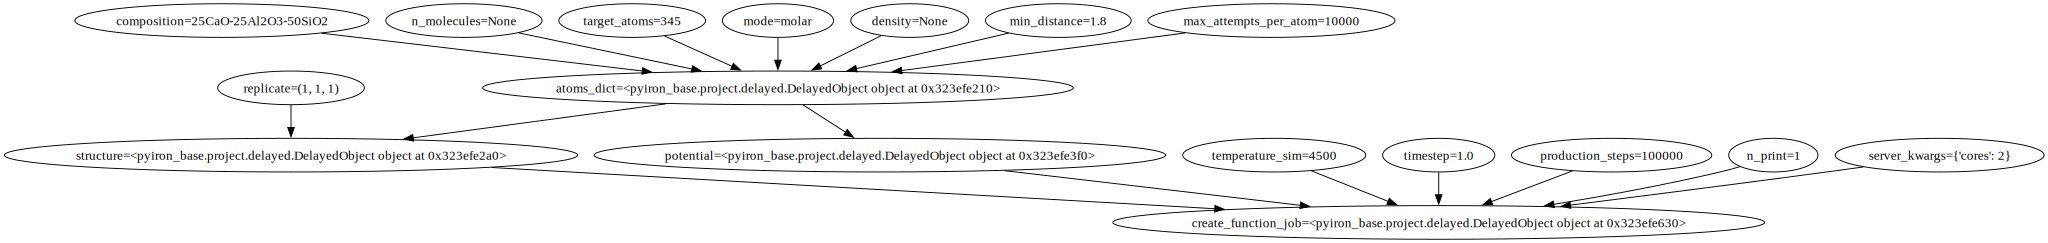

In [4]:
delayed.draw()

In [5]:
# Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
result = delayed.pull()

/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


The job viscosity_simulation_9e48719b1256e29d3a6b3d4e75f4031e was saved and received the ID: 430


/opt/homebrew/lib/python3.12/site-packages/pyiron_lammps/units.py:236: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/pyiron_lammps/units.py:236: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/pyiron_lammps/units.py:236: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/pyiron_lammps/units.py:236: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/pyiron_lammps/units.py:236: UserWarning: Warning: Couldn'

4499.7 K


Text(0, 0.5, 'Temperature [K]')

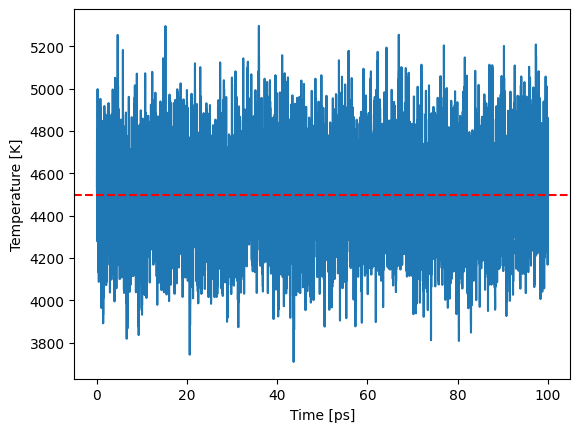

In [6]:
# Compute teh mean temperature of the last part of the simulation
import numpy as np

mean_temp = np.mean(result["result"]["temperature"])
print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
plt.plot(result["result"]["steps"] * 1e-3, result["result"]["temperature"])
plt.axhline(np.mean(result["result"]["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]")
# plt.ylim(3500, 4500)

In [7]:
pxyout = result["result"]["pressures"][:, 0, 1] * 10000
pxzout = result["result"]["pressures"][:, 0, 2] * 10000
pyzout = result["result"]["pressures"][:, 1, 2] * 10000
volumeout = result["result"]["volume"]

Processing temperature: 4500 K
Viscosity (Pa·s) at 4500 K: 0.0023215043


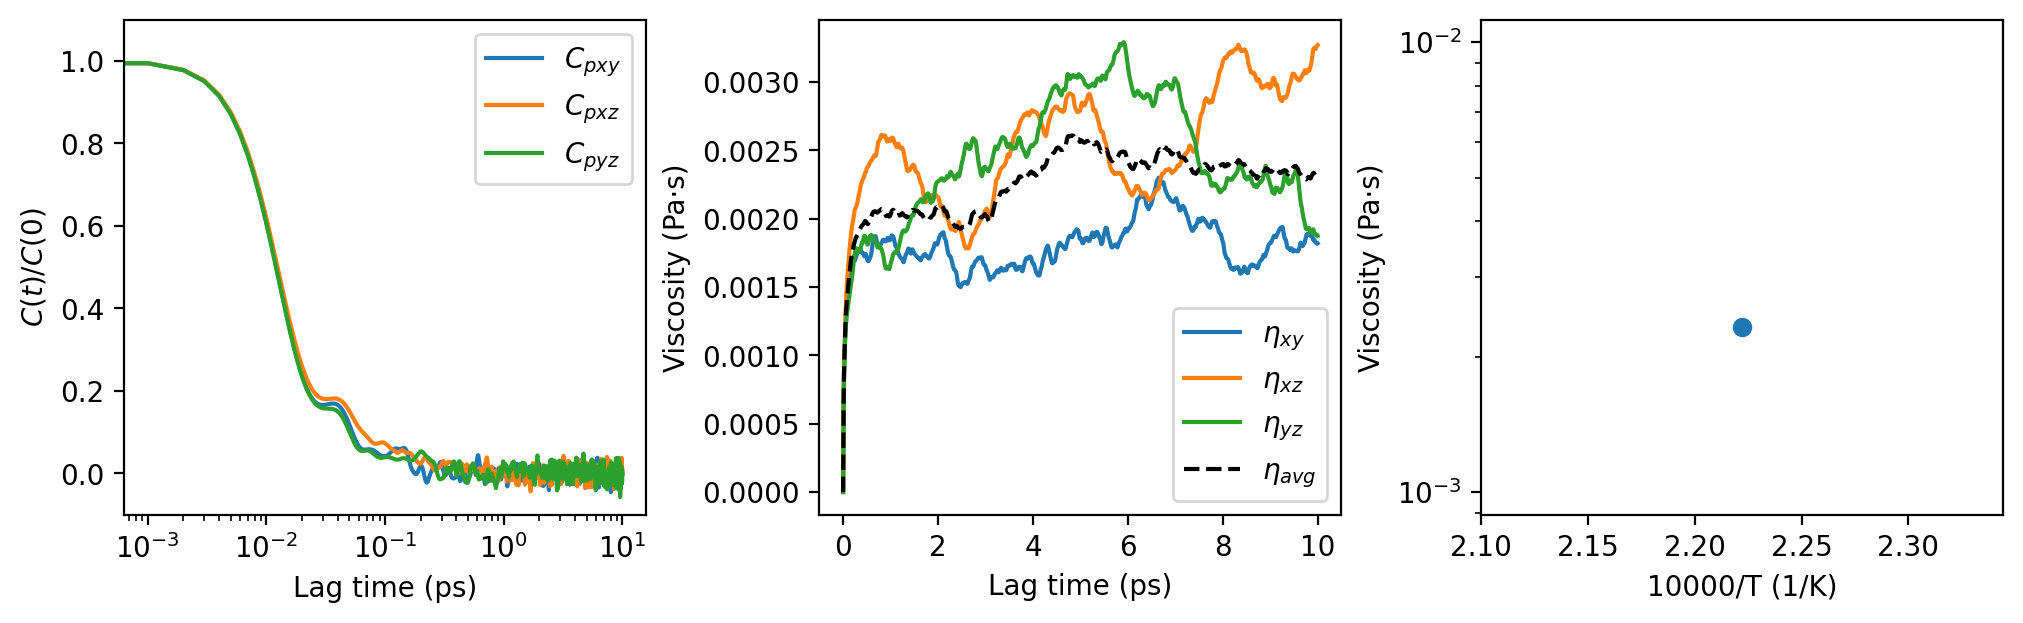

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def autocorrelation_fft(signal, max_lag):
    """
    Fast autocorrelation via FFT with normalization for multiple time origins.
    signal: (N,) array
    Returns: (max_lag,) autocorrelation
    """
    N = len(signal)
    f = np.fft.fft(signal, n=2 * N)
    acf = np.fft.ifft(f * np.conj(f))[:N].real
    norm = np.arange(N, 0, -1)
    acf /= norm
    return acf[:max_lag]


def cumulative_trapezoid(acf, dt):
    out = np.zeros_like(acf)
    for i in range(1, len(acf)):
        out[i] = out[i - 1] + 0.5 * (acf[i] + acf[i - 1]) * dt
    return out


# Example usage
if __name__ == "__main__":
    fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=200, layout="constrained")

    Temperature = np.asarray([4500])
    viscosity = np.zeros(len(Temperature))
    max_lag = 10000

    # Constants
    s = 1
    timestep_fs = 1.0
    dt_s = s * timestep_fs * 1e-15

    kB = 1.380649e-23
    bar2Pa = 1e5
    A2m = 1e-10

    for i in range(len(Temperature)):
        print(f"Processing temperature: {Temperature[i]} K")
        # Load stress components in bar
        pxy, pxz, pyz, volume = pxyout, pxzout, pyzout, volumeout
        acfxy = autocorrelation_fft(pxy, max_lag)
        acfxz = autocorrelation_fft(pxz, max_lag)
        acfyz = autocorrelation_fft(pyz, max_lag)
        volume_A3 = volume[0]
        volume_m3 = volume_A3 * A2m**3

        acfxy *= bar2Pa**2
        acfxz *= bar2Pa**2
        acfyz *= bar2Pa**2

        scale = volume_m3 / (kB * Temperature[i])

        eta_xy_running = scale * cumulative_trapezoid(acfxy, dt_s)
        eta_xz_running = scale * cumulative_trapezoid(acfxz, dt_s)
        eta_yz_running = scale * cumulative_trapezoid(acfyz, dt_s)
        eta_avg_running = (eta_xy_running + eta_xz_running + eta_yz_running) / 3.0

        eta = eta_avg_running[-10:].mean()
        viscosity[i] = eta
        print(f"Viscosity (Pa·s) at {Temperature[i]} K: {eta:.10f}")

        lag_time_fs = np.arange(max_lag) * s * timestep_fs

        acfxy /= bar2Pa**2
        acfxz /= bar2Pa**2
        acfyz /= bar2Pa**2

        ax[0].plot(lag_time_fs / 1000, acfxy / acfxy[0], label=r"$C_{pxy}$")
        ax[0].plot(lag_time_fs / 1000, acfxz / acfxz[0], label=r"$C_{pxz}$")
        ax[0].plot(lag_time_fs / 1000, acfyz / acfyz[0], label=r"$C_{pyz}$")
        ax[0].set_xscale("log")
        # ax[0].set_xlim(0, max_lag * s * timestep_fs)
        ax[0].set_ylim(-0.1, 1.1)
        ax[0].set_xlabel("Lag time (ps)")
        ax[0].set_ylabel(r"$C(t)/C(0)$")
        ax[0].legend()

        ax[1].plot(lag_time_fs / 1000, eta_xy_running, label=r"$\eta_{xy}$")
        ax[1].plot(lag_time_fs / 1000, eta_xz_running, label=r"$\eta_{xz}$")
        ax[1].plot(lag_time_fs / 1000, eta_yz_running, label=r"$\eta_{yz}$")
        ax[1].plot(lag_time_fs / 1000, eta_avg_running, "k--", label=r"$\eta_{avg}$")
        ax[1].set_xlabel("Lag time (ps)")
        ax[1].set_ylabel("Viscosity (Pa·s)")
        ax[1].legend()

        ax[2].plot(10000 / Temperature, viscosity, marker="o", label="Viscosity")
        ax[2].set_xlabel("10000/T (1/K)")
        ax[2].set_ylabel("Viscosity (Pa·s)")
        ax[2].set_yscale("log")
        # ax[1].legend()
        # plt.savefig("viscosity_results.png", dpi=600)
    plt.show()